In [85]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pytesseract
import easyocr
import pandas as pd
import skimage.filters as threshold_sauvola

In [86]:
def display(img):
    cv2.imshow("img",img)
    cv2.waitKey(0)

In [87]:
def preprocess_and_deskew(image_path, save_path):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    contrast_enhanced = clahe.apply(img)

    
    denoised = cv2.bilateralFilter(contrast_enhanced, 9, 75, 75)

    
    binarized = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 5,5
    )

    
    edges = cv2.Canny(binarized, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    angles = []
    if lines is not None:
        for rho, theta in lines[:, 0]:
            angle = (theta * 180 / np.pi) - 90
            if -45 < angle < 45:
                angles.append(angle)

    
    skew_angle = np.median(angles) if angles else 0

    # Deskew only if needed
    (h, w) = binarized.shape[:2]
    if abs(skew_angle) > 1:
        center = (w // 2, h // 2)
        rot_matrix = cv2.getRotationMatrix2D(center, skew_angle, 1.0)
        deskewed = cv2.warpAffine(binarized, rot_matrix, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    else:
        deskewed = binarized

    
    cv2.imwrite(save_path, deskewed)
    plt.figure(figsize=(8, 6))
    plt.axis("off")
    plt.imshow(deskewed, cmap="gray")
    plt.show()

    return save_path       

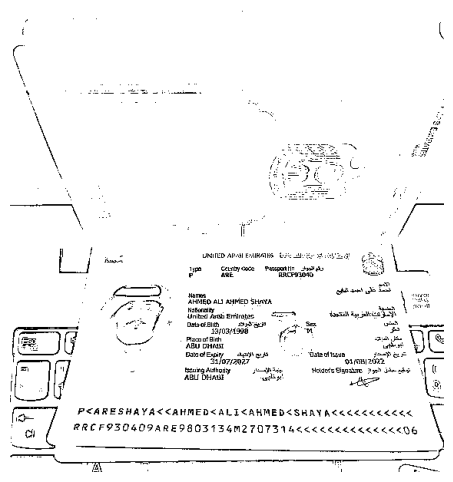

'temp_pass/preprocessed.jpg'

In [88]:
preprocess_and_deskew("passport/10.PNG","temp_pass/preprocessed.jpg")

In [89]:
def dilated_passport(image_path, save_path):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    inverted = cv2.bitwise_not(img)
    
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(inverted, cv2.MORPH_CLOSE, kernel, iterations=2)

    dilated = cv2.dilate(closed, np.ones((2,2), np.uint8), iterations=3)
    
    cv2.imwrite(save_path, dilated)
    plt.figure(figsize=(6, 4))
    plt.axis("off")
    plt.imshow(dilated, cmap="gray")
    plt.show()

    return save_path
   

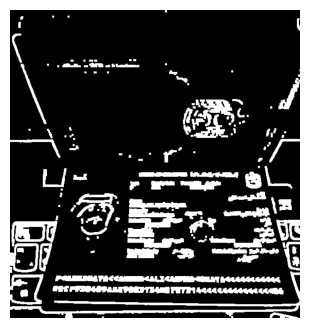

'temp_pass/dilated.jpg'

In [90]:
dilated_passport("temp_pass/preprocessed.jpg", "temp_pass/dilated.jpg")

In [91]:
def detect_mrz_contours_and_extract_text(dilated_image_path, original_image_path):
    
    dilated = cv2.imread(dilated_image_path, cv2.IMREAD_GRAYSCALE)
    original = cv2.imread(original_image_path)
    reader=easyocr.Reader(['en'])
    
    if dilated is None or original is None:
        raise ValueError("Error loading one or both images.")

    
    contours, _ = cv2.findContours(dilated, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    
    height, width = original.shape[:2]

    
    mrz_contours = []

      

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)

        
        if (
            w > 0.5 * width and  # Wide enough
            h < 0.3 * height and  # Not too tall
            y > 0.4 * height and  # Positioned lower in the image
            area > 1200  # Ignore small noise
        ):
            mrz_contours.append((x, y, w, h))

    
    mrz_contours = sorted(mrz_contours, key=lambda c: c[1])


    
    for i, (x, y, w, h) in enumerate(mrz_contours):
        
        cv2.rectangle(original, (x, y), (x + w, y + h), (0, 255, 0), 2) 
        
        cropped_mrz = original[y:y + h, x:x + w]

        
        cropped_filename = f"mrz_crop_{i}.jpg"
        cv2.imwrite(cropped_filename, cropped_mrz)
        cv2.imshow(f"Cropped MRZ {i+1}", cropped_mrz)

        
        easyocr_text = reader.readtext(cropped_mrz, detail=0)
        
        custom_config = r'--oem 3 --psm 6' 
        
        pytesseract_text = pytesseract.image_to_string(cropped_mrz,config=custom_config)

        
        
        print("EasyOCR Result:\n", easyocr_text)
        print("Pytesseract Result:\n", pytesseract_text)

    
    cv2.imshow("MRZ Contours", original)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


detect_mrz_contours_and_extract_text("temp_pass/dilated.jpg", "temp_pass/preprocessed.JPG")



Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR Result:
 ['P<ARESHAYA<(AMMED<ALI<AHMED<SHAYA<<<<4<<44< <', 'RrcF930409ARE9803', '34M2707314<<<<644<<4<6<006']
Pytesseract Result:
 PARE SHAY A<CAHMED<ALE<AHMEDSSHAY ACK KEKE KEK
RRO FOSOGOPARE 9803 154M2 TOTS 1 HK KK KKK LK KKK KEDE

